Путинцев Кирилл гр. 8Е21 

Для 1 лаб работы по CV необходимо реализовать базовый минимум операций над изображениями
Входное изображение в формате (RGB, не чёрно-белое)
1.Фильтры  
1.1 Медианный фильтр  
1.2 Фильтр гаусса  
2.Морфологические операции  
2.1 Эрозия  
2.2 Дилатация  
3.Прочие операции  
3.1 пороговая бинаризация (для rgb и grayscale изображения)  
3.2 выравнивание гистограммы  
3.3 поворот изображений на угол кратный 90 градусов  

Использовать методы OpenCV для реализации операций нельзя. Допустимы только методы cv2.imread() и cv2.imshow(). 
Все методы должны быть реализованы вручную.

Для начала подключим необходимые библиотеки

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

После подключения библиотек необходимо подгрузить изображение для обработки

Изображение загружено. Размер: (200, 200, 3)


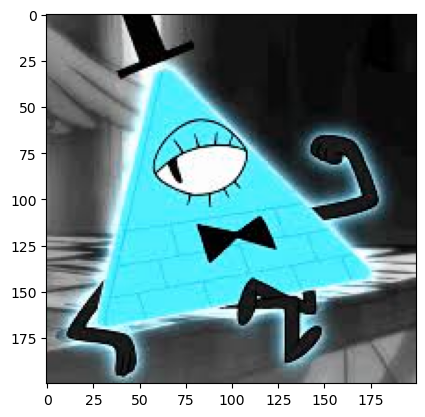

In [2]:
# Просто указываем имя файла
import cv2
image = cv2.imread('Kent.png')

# Проверка, что изображение загрузилось
if image is None:
    print("Ошибка: изображение не найдено!")
else:
    print(f"Изображение загружено. Размер: {image.shape}")
    plt.imshow(image)
    plt.show

Изображение имеет непривычный вид. Это связано с тем, что opencv отображает по умолчанию изображения в RGB фотрмате, а в BGR. Давайте исправим данную оплошность. Воспользуемся встроенной функцией перевода изображений в разные цветовые пространства: cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

<function matplotlib.pyplot.show(close=None, block=None)>

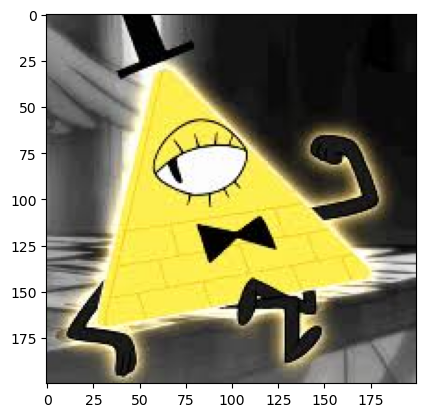

In [3]:
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show

# 1. Фильтры  
В контексте данной лабораторной работы фильтры используются для борьбы с шумом на изображениях. Шум бывает нескольких видов, рассмотрим наиболее распространенные. Первый - это шум, который подвержен нормальному закону распределния (Гаусов шум). Второй - шум связанный с засветами и проблемами матрицы (Импульсный шум, или шум вида "Соль и Перец"). 
   

### Медианный фильтр 
Медианный фильтр хорошо справляется с шумом вида "Соль и перец".  
Принцип работы следующий:  
Создается "окно" для проверки. При прохождении окна по изборажению числа внутри располагаются по возрастанию/убыванию. Берется среднее число из этого ряда.  
Тем самым при прохождении убираются выбросы черных и белых пикселей.

Применим данный фильтр для исходного изображения

In [4]:
def median_filter(image, kernel_size):
    height, width, channels = image.shape

    # Вброс ошибки при четном размере свертки 
    if kernel_size % 2 == 0:
        raise ValueError("Размер ядра должен быть нечетным числом")

    # Автоподбор отраженного края изображенного
    pad = kernel_size // 2

    # Отражение крайних пикселей
    padded_image = np.pad(image,
                         pad_width=((pad, pad), (pad, pad), (0, 0)),
                         mode='reflect')

    # Создание массива для записи отфильтрованного изображения
    filtered_image = np.zeros_like(image)

    # Цикл фильтра
    for i in range(height):
        for j in range(width):
            for c in range(channels):
                window = padded_image[i:i + kernel_size,
                                      j:j + kernel_size,
                                      c]

                median_value = np.median(window)
                filtered_image[i, j, c] = median_value

    # На всякий возвращаем тип данных (может во флоте вернуть)
    filtered_image = filtered_image.astype(image.dtype)

    return filtered_image

Теперь проверим работу фильтра на исходном изображении.
    

Медианный фильтр


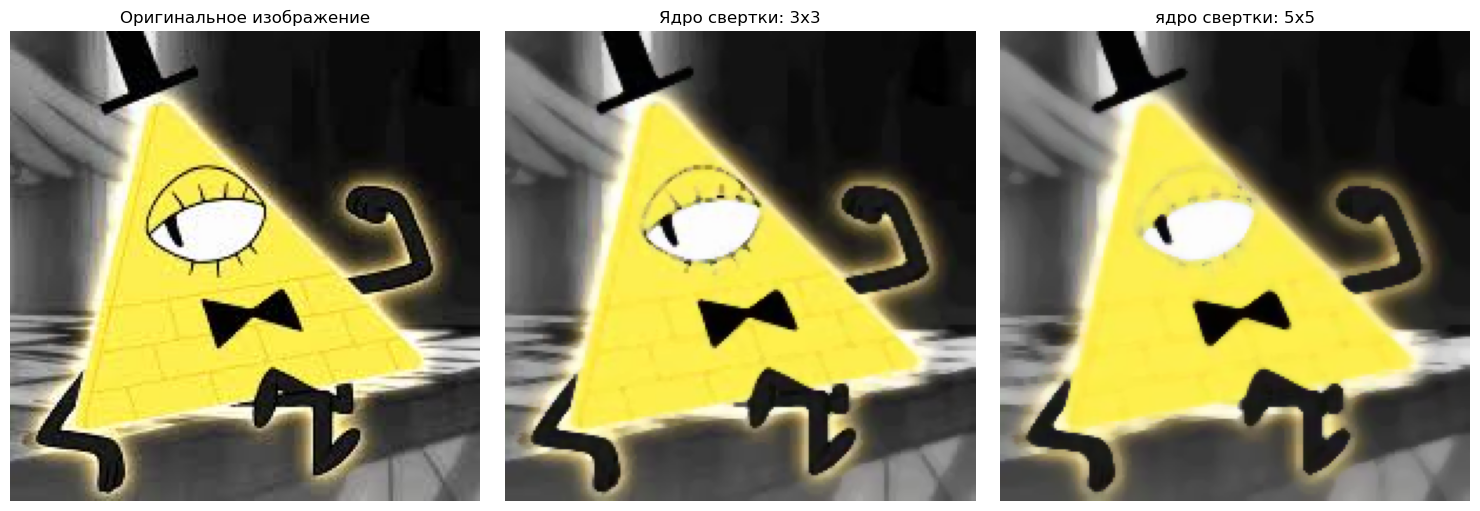

In [5]:
print ("Медианный фильтр")
filtered_image_k3=median_filter(image, kernel_size=3)
filtered_image_k5=median_filter(image, kernel_size=5)
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title('Оригинальное изображение')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(filtered_image_k3)
plt.title('Ядро свертки: 3x3')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(filtered_image_k5)
plt.title('ядро свертки: 5x5')
plt.axis('off')

plt.tight_layout()
plt.show()

Для более явного примера используем изображение с шумом типа "соль и перец"

Медианный фильтр


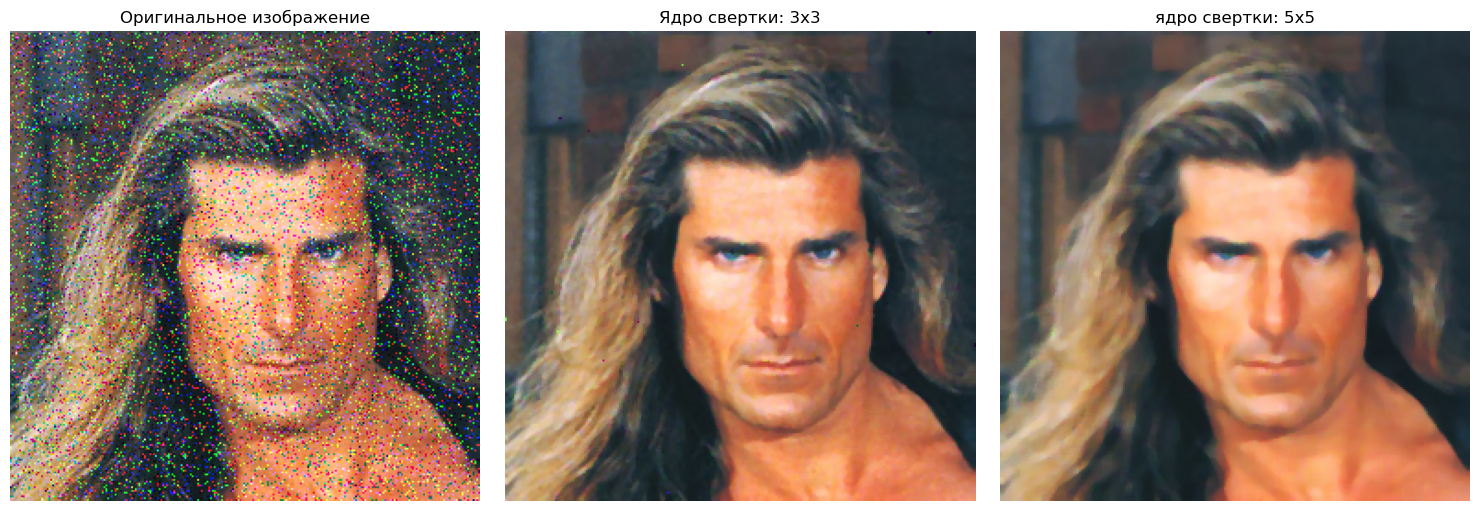

In [6]:
Saltman = cv2.imread('Saltman.png')
Saltman = cv2.cvtColor(Saltman, cv2.COLOR_BGR2RGB)

print ("Медианный фильтр")
filtered_image_k3=median_filter(Saltman, kernel_size=3)
filtered_image_k5=median_filter(Saltman, kernel_size=5)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(Saltman)
plt.title('Оригинальное изображение')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(filtered_image_k3)
plt.title('Ядро свертки: 3x3')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(filtered_image_k5)
plt.title('ядро свертки: 5x5')
plt.axis('off')

plt.tight_layout()
plt.show()

Как мы видим медианный фильтр, а в частности медианный фильтр с ядром свертки 3*3  
справляется просто великолепно. При использовании данного фильтра с ядром свертки 5*5 изображение размывается

### Фильтр Гаусса
Фильтр Гаусса — это линейный фильтр, который выполняет сглаживание изображения с использованием ядра, веса в котором распределены по нормальному закону. Данный фильтр подходит для подготовки изображения к последующей обработке (размытие) и для удаления высокочастотного шума (фильтр низких частот) 

Применим данный фильтр для исходного изображения

In [7]:
def gaussian_kernel(kernel_size, sigma):

    # Вброс ошибки при четном размере свертки
    if kernel_size % 2 == 0:
        raise ValueError("Размер ядра должен быть нечетным числом")

    # Создаем шаблон ядра
    kernel = np.zeros((kernel_size, kernel_size), dtype=np.float32)
    
    # Определяем константы
    center = kernel_size//2
    constant = 1/ (2*np.pi * sigma**2)
    sum_value = 0

    # Собираем ядро Гаусса
    for i in range(kernel_size):
        for j in range(kernel_size):
            x = i - center
            y = j - center
            exponent = -(x**2 + y**2)/ (2*sigma**2)
            kernel[i,j]=constant*np.exp(exponent)
            sum_value += kernel[i,j]
            
    # Нормализуем данные
    kernel = kernel / sum_value
    return kernel

In [8]:
def gaussian_filter(image, kernel_size, sigma):
    height, width, channels = image.shape

    # Создаем свертку с формулой Гаусса
    kernel=gaussian_kernel(kernel_size, sigma)

    # Автоподбор отраженного края изображенного
    pad = kernel_size // 2

    # Отражение крайних пикселей
    padded_image = np.pad(image,
                         pad_width=((pad, pad), (pad, pad), (0, 0)),
                         mode='reflect')

    # Создание массива для записи отфильтрованного изображения
    filtered_image = np.zeros_like(image)

    # Цикл фильтра
    for i in range(height):
        for j in range(width):
            for c in range(channels):
                window = padded_image[i:i + kernel_size,
                                      j:j + kernel_size,
                                      c]
                gaus_value = np.sum(window*kernel)
                filtered_image[i, j, c] = np.clip(gaus_value, 0, 255)

    # На всякий возвращаем тип данных (может во флоте вернуть)
    filtered_image = filtered_image.astype(image.dtype)

    return filtered_image

Фильтр Гаусса


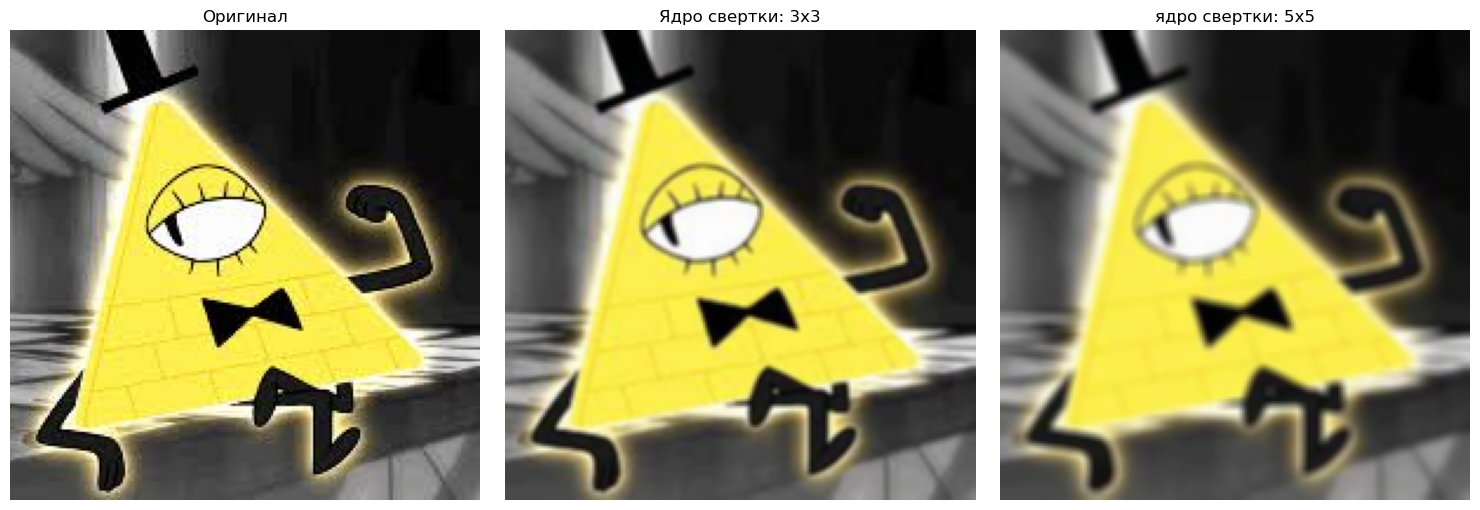

In [9]:
print ("Фильтр Гаусса")
filtered_image_k3=gaussian_filter(image, kernel_size=3, sigma=1)
filtered_image_k5=gaussian_filter(image, kernel_size=5, sigma=2)
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title('Оригинал')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(filtered_image_k3)
plt.title('Ядро свертки: 3x3')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(filtered_image_k5)
plt.title('ядро свертки: 5x5')
plt.axis('off')

plt.tight_layout()
plt.show()

Фильтр Гаусса


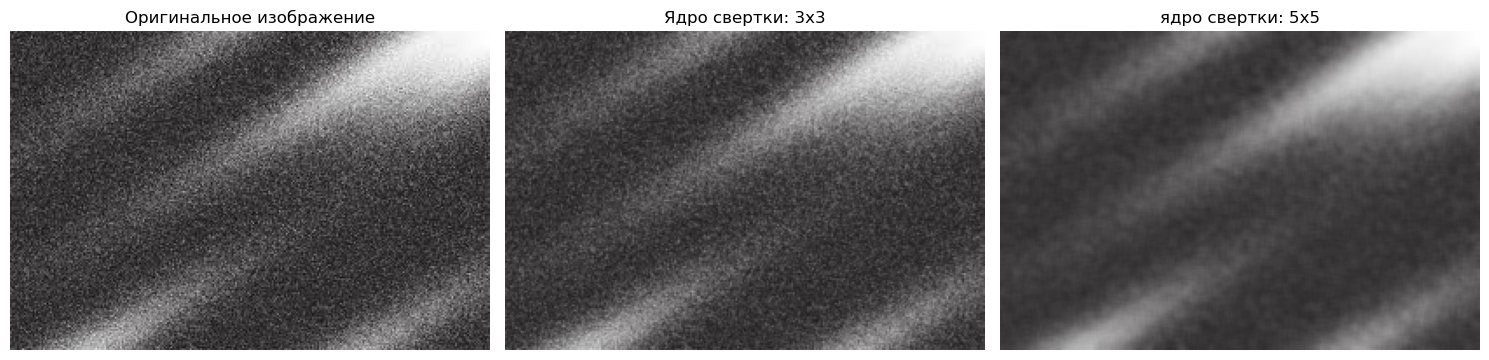

In [33]:
Sigma = cv2.imread('Sigma.png')
Sigma = cv2.cvtColor(Sigma, cv2.COLOR_BGR2RGB)

print ("Фильтр Гаусса")
filtered_image_k3=gaussian_filter(Sigma, kernel_size=3, sigma=0.5)
filtered_image_k5=gaussian_filter(Sigma, kernel_size=5, sigma=4)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(Sigma)
plt.title('Оригинальное изображение')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(filtered_image_k3)
plt.title('Ядро свертки: 3x3')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(filtered_image_k5)
plt.title('ядро свертки: 5x5')
plt.axis('off')

plt.tight_layout()
plt.show()

Отлично, все работает идем дальше

# 2.Морфологические операции
Морфологические операции - это методы обработки изображений, основанные на форме объектов, которые применяются с использованием структурного элемента (ядра). Основные операции - эрозия и дилатация: эрозия "съедает" границы объектов, удаляя мелкие выступы и разъединяя слипшиеся элементы, а дилатация "расширяет" границы, заполняя дыры и соединяя близкие объекты. На их основе строятся открытие (эрозия + дилатация) для удаления шума и закрытие (дилатация + эрозия) для заполнения полостей. Эти операции применяются для предобработки изображений.

Для упрощения задачи преобразуем изображение в ЧБ

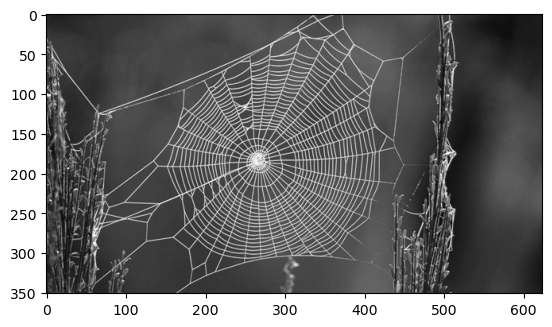

In [11]:
image_2 = cv2.imread('Juke.png')
image_2 = cv2.cvtColor(image_2, cv2.COLOR_BGR2GRAY)
plt.imshow(image_2, cmap='gray')

In [12]:
def dilation_manual(image, kernel_size, iterations):
    if image is None:
        raise ValueError("Изображение не загружено!")

    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image.copy()

    kernel = np.ones((kernel_size, kernel_size), dtype=np.uint8)
    kernel_h, kernel_w = kernel.shape
    pad_h, pad_w = kernel_h // 2, kernel_w // 2

    current_image = gray.copy().astype(np.uint8)

    for iteration in range(iterations):
        # Добавляем отступы
        padded_image = np.pad(current_image,
                             pad_width=((pad_h, pad_h), (pad_w, pad_w)),
                             mode='constant',
                             constant_values=0)

        dilated = np.zeros_like(current_image)

        # Проходим по каждому пикселю
        for i in range(current_image.shape[0]):
            for j in range(current_image.shape[1]):
                # Извлекаем окно
                window = padded_image[i:i + kernel_h, j:j + kernel_w]

                # Применяем ядро
                masked_window = window * kernel

                # Дилатация: берем максимум в окне с учетом ядра
                if np.any(kernel):  # если ядро не пустое
                    dilated[i, j] = np.max(masked_window)
                else:
                    dilated[i, j] = 0

        current_image = dilated

    return current_image

In [13]:
def erosion_manual(image, kernel_size, iterations):
    if image is None:
        raise ValueError("Изображение не загружено!")

    # Преобразуем в grayscale
    if len(image.shape) == 3:
        grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        grey = image.copy()

    # Создаем квадратное ядро
    kernel = np.ones((kernel_size, kernel_size), dtype=np.uint8)

    kernel_h, kernel_w = kernel.shape
    pad_h, pad_w = kernel_h // 2, kernel_w // 2

    current_image = grey.copy().astype(np.uint8)

    for iteration in range(iterations):
        # Добавляем границы
        padded_image = np.pad(current_image,
                             pad_width=((pad_h, pad_h), (pad_w, pad_w)),
                             mode='constant',
                             constant_values=255)

        eroded = np.zeros_like(current_image)  

        for i in range(current_image.shape[0]):
            for j in range(current_image.shape[1]):
                window = padded_image[i:i + kernel_h, j:j + kernel_w]

                # Применяем ядро
                masked_window = window * kernel

                kernel_positions = kernel > 0
                if np.any(kernel_positions):
                    if np.all(masked_window[kernel_positions] > 0):
                        # Берем минимум среди соответствующих пикселей
                        eroded[i, j] = np.min(masked_window[kernel_positions])
                    else:
                        eroded[i, j] = 0
                else:
                    eroded[i, j] = 0

        current_image = eroded

    return current_image

Применяем расширение


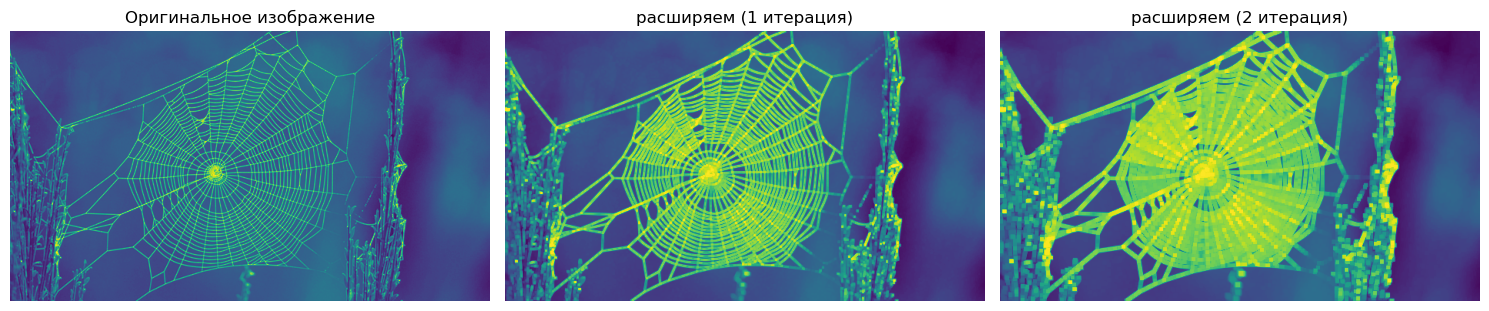

Применяем эрозию:


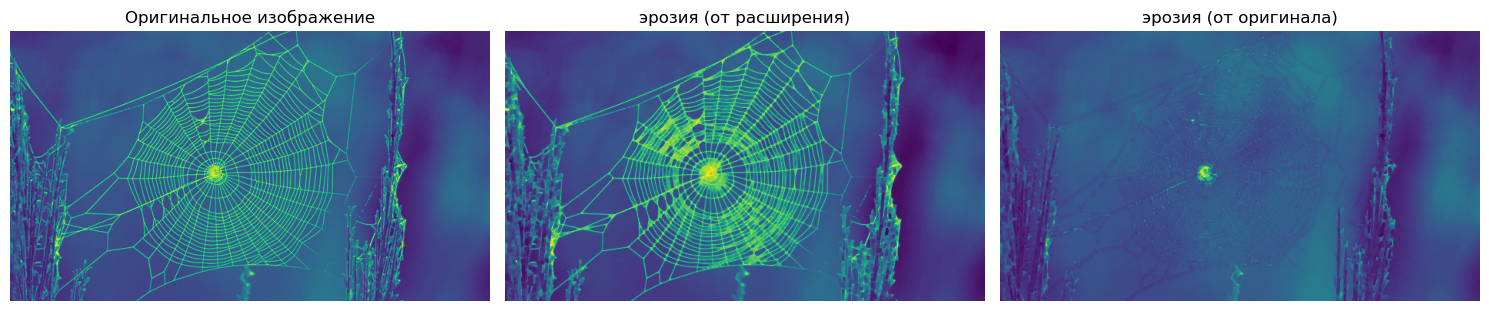

In [16]:
print("Применяем расширение")
image_a = dilation_manual(image_2, kernel_size=3, iterations=1)
image_b = dilation_manual(image_2, kernel_size=3, iterations=2)
image_c = erosion_manual(image_a, kernel_size=3, iterations=1)
image_d = erosion_manual(image_2, kernel_size=3, iterations=1)

# Отображаем Гауссовы фильтры
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_2)
plt.title('Оригинальное изображение')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(image_a)
plt.title('расширяем (1 итерация)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(image_b)
plt.title('расширяем (2 итерация)')
plt.axis('off')

plt.tight_layout()
plt.show()

print("Применяем эрозию:")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_2)
plt.title('Оригинальное изображение')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(image_c)
plt.title('эрозия (от расширения)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(image_d)
plt.title('эрозия (от оригинала)')
plt.axis('off')

plt.tight_layout()
plt.show()

# 3.Прочие операции
### Пороговая бинаризация
Пороговая бинаризация — это метод обработки изображений, преобразующий полутоновое или цветное изображение в черно-белое (бинарное). Метод разделяет объект и фон, присваивая пикселям, яркость которых выше заданного порога, белый цвет, а ниже — черный. Это основной инструмент для сегментации и выделения контуров объектов.

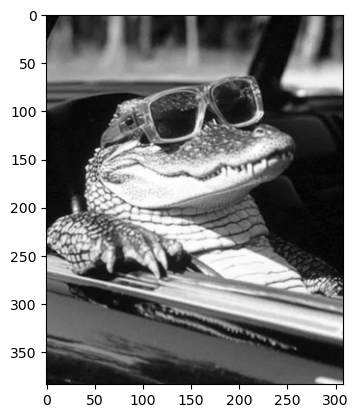

In [17]:
image_Bin = cv2.imread('Bin.png')
image_Bin = cv2.cvtColor(image_Bin, cv2.COLOR_BGR2GRAY)
plt.imshow(image_Bin, cmap='gray')

In [18]:
def binar(image, bin_level):
    if image is None:
        raise ValueError("Изображение не загружено!")
        
    image_copy=image.copy()

    height, width = image.shape

    # Цикл фильтра
    for i in range(height):
        for j in range(width):
            if image_copy[i][j]<=bin_level:
                image_copy[i][j]=0
            else:
                image_copy[i][j]=1                

    return image_copy

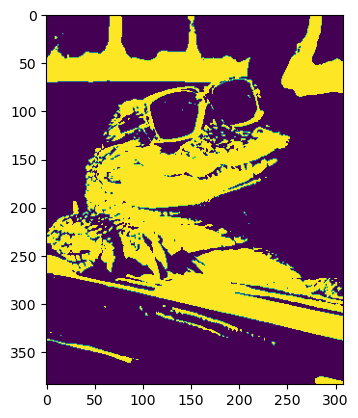

In [37]:
bin= binar(image_Bin, bin_level=130)
plt.imshow(bin)

 ### Выравнивание гистограммы
Выравнивание гистограммы (эквализация) — это метод обработки изображений, который улучшает контрастность путем перераспределения интенсивностей пикселей так, чтобы результирующая гистограмма была максимально плоской и равномерной.

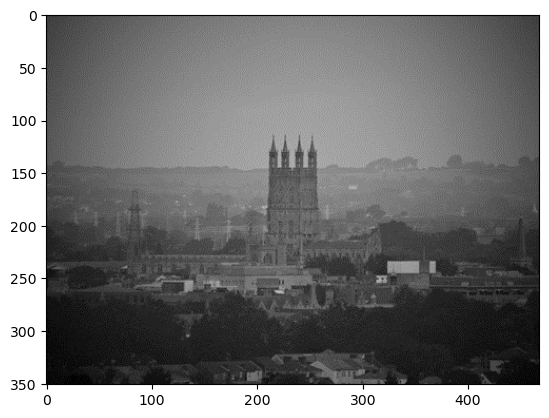

In [20]:
image_G = cv2.imread('Gorod.png')
plt.imshow(image_G, cmap='gray')

In [21]:
def gray_img(image):
    
    if len(image.shape) == 2:
        return image.copy()

    height, width, channels = image.shape
    gray = np.zeros((height, width), dtype=np.uint8)

    for i in range(height):
        for j in range(width):
            gray[i, j] = int((int(image[i, j, 0]) + int(image[i, j, 1]) + int(image[i, j, 2])) / 3)

    return gray

In [22]:
def histogram(image):
    histogramm = np.zeros(256, dtype=np.int32)

    if len(image.shape) == 3:
        # Если цветное, преобразуем в grayscale
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        height, width = gray.shape
        img = gray
    else:
        height, width = image.shape
        img = image
    
    for i in range(height):
        for j in range(width):
            pixel_value = img[i, j]
            histogramm[pixel_value] += 1
    
    return histogramm

посмотрим сколько пикселей имеет яркость до какого-нибудь значения сделаем функцию CDF

In [23]:
def cdf_с(histogram):
    # Создаем массив заполненный нулями
    cdf = np.zeros_like(histogram, dtype=np.float32)
    cdf[0] = histogram[0]

    for i in range(1, len(histogram)):
        cdf[i] = cdf[i-1] + histogram[i]

    return cdf

In [24]:
def normalize_cdf(cdf, image):

    # находим общее количество пикселей
    all_pixels = image.shape[0] * image.shape[1]
    
    # ИЩем минимальное ненулевое значение
    cdf_nonzero = cdf[cdf > 0]
    if len(cdf_nonzero) > 0:
        cdf_min = np.min(cdf_nonzero)
    else:
        cdf_min = 0

    cdf_normalized = np.zeros_like(cdf, dtype=np.uint8)

    for i in range(len(cdf)):
        if cdf[i] > 0:
            cdf_normalized[i] = round((cdf[i] - cdf_min) * 255 / (all_pixels - cdf_min))
        else:
            cdf_normalized[i] = 0

    return cdf_normalized

In [25]:
def histogram_normalize(image):
    total_pixels = image.shape[0] * image.shape[1]

    g_m=gray_img(image)
    hist = histogram(g_m)         
    cdf = cdf_с(hist)                   
    lookup_table = normalize_cdf(cdf, g_m)  

    normalize = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            original_value = g_m[i, j]
            normalize[i, j] = lookup_table[original_value] 

    return normalize

Оригинал:


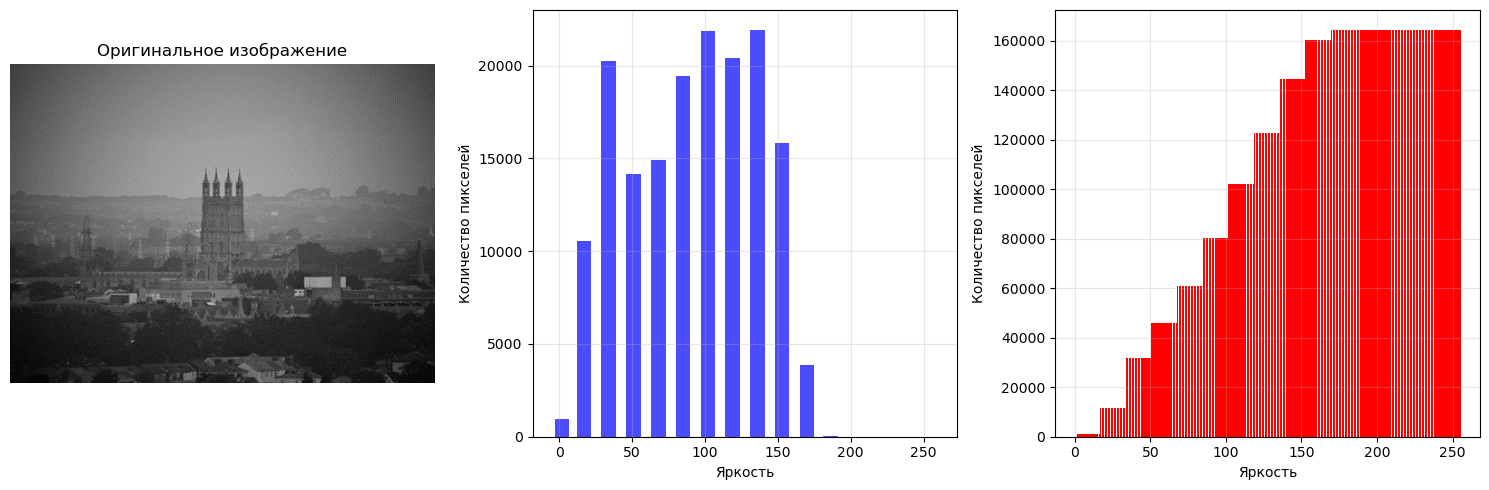

После преобразований:


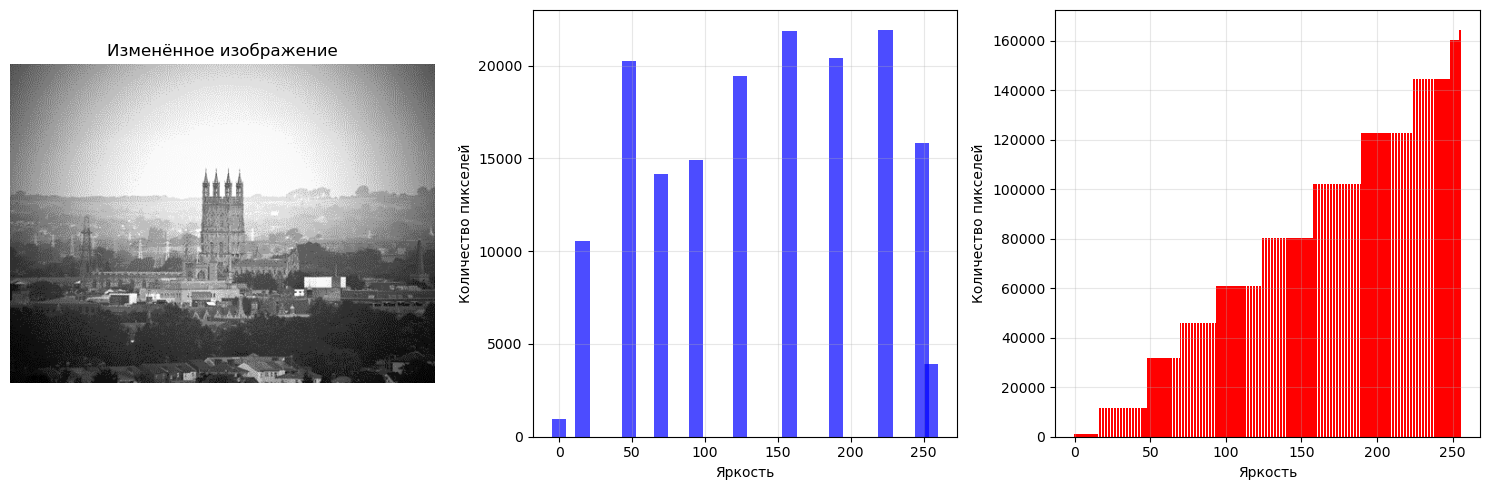

In [31]:
hist=histogram(image_G)
cdf_h = cdf_с(hist)

plt.figure(figsize=(15, 5))

print("Оригинал:")

plt.subplot(1, 3, 1)
plt.imshow(image_G)
plt.title('Оригинальное изображение')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.bar(range(256), hist, color='blue', alpha=0.7, width=10)
plt.xlabel('Яркость')
plt.ylabel('Количество пикселей')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.bar(range(256), cdf_h, color='red', linewidth=2)
plt.xlabel('Яркость')
plt.ylabel('Количество пикселей')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("После преобразований:")

Normal=histogram_normalize(image_G)
Normal_hist=histogram(Normal)
cdf_n = cdf_с(Normal_hist)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(Normal)
plt.title('Изменённое изображение')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.bar(range(256), Normal_hist, color='blue', alpha=0.7, width=10)
plt.xlabel('Яркость')
plt.ylabel('Количество пикселей')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.bar(range(256), cdf_n, color='red', linewidth=2)
plt.xlabel('Яркость')
plt.ylabel('Количество пикселей')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Оригинал:


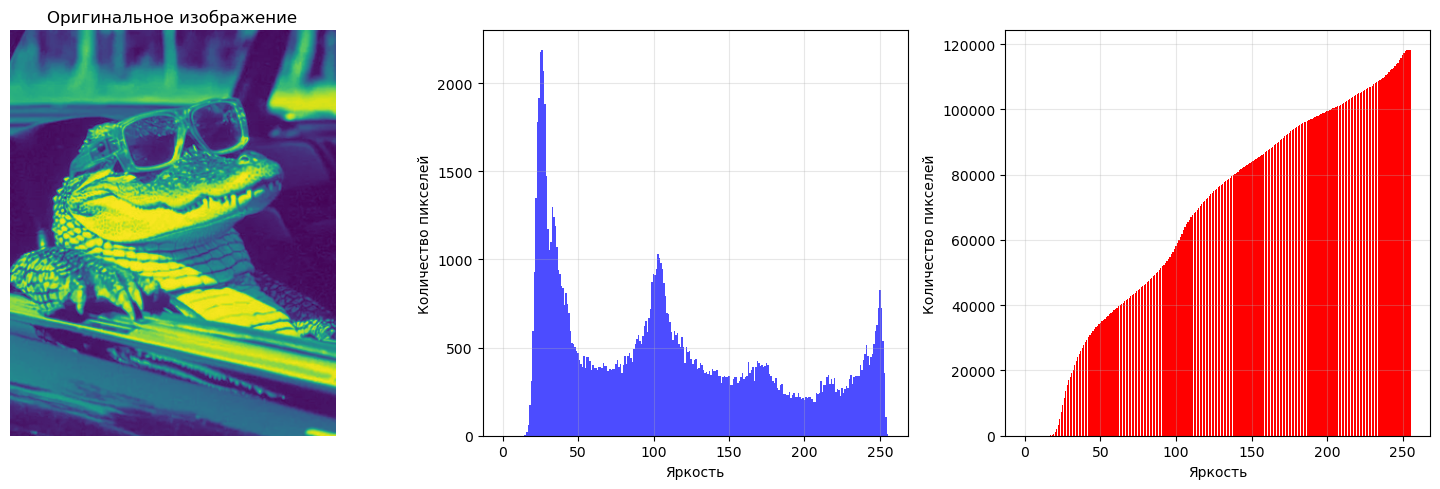

После преобразований:


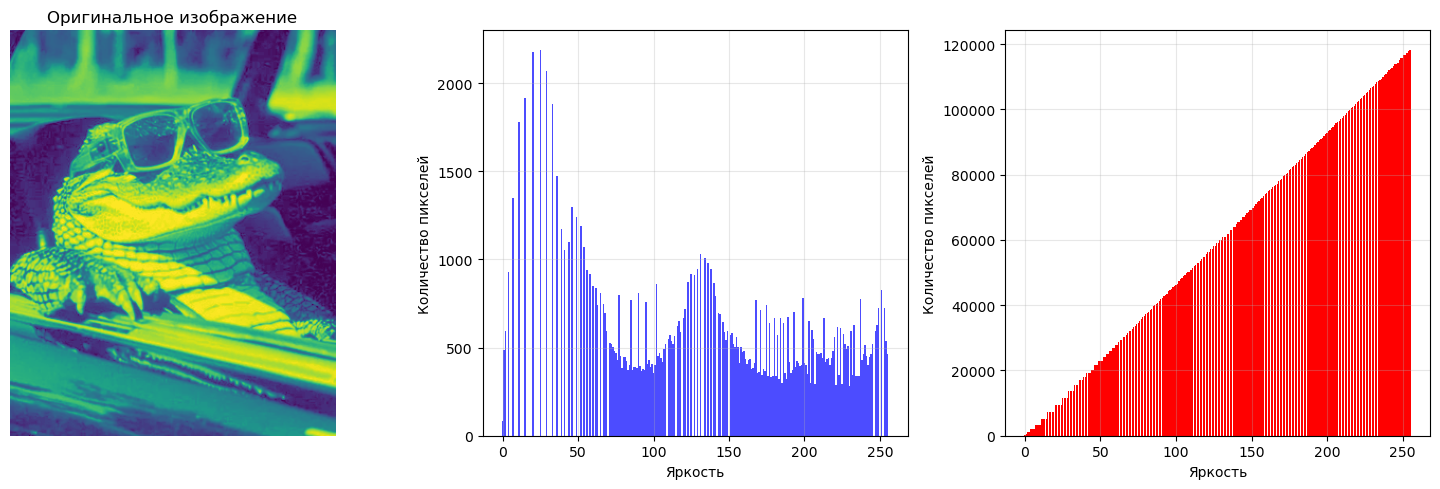

In [27]:
hist=histogram(image_Bin)
cdf_h = cdf_с(hist)

plt.figure(figsize=(15, 5))

print("Оригинал:")

plt.subplot(1, 3, 1)
plt.imshow(image_Bin)
plt.title('Оригинальное изображение')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.bar(range(256), hist, color='blue', alpha=0.7, width=1)
plt.xlabel('Яркость')
plt.ylabel('Количество пикселей')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.bar(range(256), cdf_h, color='red', linewidth=2)
plt.xlabel('Яркость')
plt.ylabel('Количество пикселей')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("После преобразований:")

Normal=histogram_normalize(image_Bin)
Normal_hist=histogram(Normal)
cdf_n = cdf_с(Normal_hist)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(Normal)
plt.title('Оригинальное изображение')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.bar(range(256), Normal_hist, color='blue', alpha=0.7, width=1)
plt.xlabel('Яркость')
plt.ylabel('Количество пикселей')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.bar(range(256), cdf_n, color='red', linewidth=2)
plt.xlabel('Яркость')
plt.ylabel('Количество пикселей')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Повороты

In [28]:
def rotate(image, angle):
    if angle % 90 != 0:
        raise ValueError("АУ, угол кратный 90 градусам бро!!!")

    iteration=angle // 90
    result=image.copy()
    
    if angle != 0:
        for z in range (iteration):
            ht, wt= result.shape[:2]  
            if len(result.shape) == 3:
                ch=result.shape[2]  
                rotated = np.zeros((wt, ht, ch), dtype=result.dtype)
                for i in range(ht):
                    for j in range(wt):
                        for k in range(ch):
                            rotated[j, ht-1-i,k] = result[i, j, k]  
            else:
                rotated = np.zeros((wt, ht), dtype=result.dtype)
                for i in range(ht):
                    for j in range(wt):
                        rotated[j, ht-1-i] = result[i, j]
            result=rotated

    return result

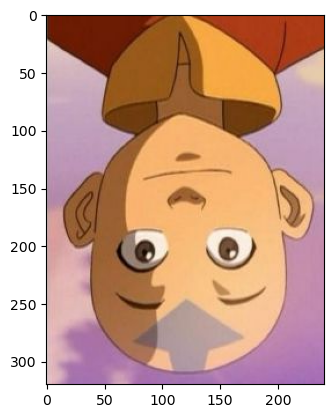

In [32]:
Aang = cv2.imread('Strela.png')
Aang = cv2.cvtColor(Aang, cv2.COLOR_BGR2RGB)
bin= rotate(Aang, angle=900)
plt.imshow(bin)